In [1]:
# ── Cell 1: Environment Setup ────────────────────────────────
import os
os.environ["HADOOP_HOME"]     = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"]            = r"C:\hadoop\bin;" + os.environ.get("PATH", "")
assert os.path.exists(r"C:\hadoop\bin\winutils.exe"), "winutils.exe missing!"
print("✓ HADOOP_HOME set")


✓ HADOOP_HOME set


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, IntegerType,
                                StringType, DoubleType, ArrayType)
from pyspark.ml.clustering import KMeans, BisectingKMeans, LDA
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.functions import array_to_vector   # JVM-only, no Python worker

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import time, json, pickle
from sklearn.cluster import KMeans as SKLearnKMeans
from sklearn.mixture import GaussianMixture as SKLearnGMM
from sklearn.metrics import silhouette_score as sk_silhouette
from sklearn.preprocessing import normalize

In [3]:
# ── Cell 3: SparkSession ─────────────────────────────────────
spark = SparkSession.builder \
    .appName("BagOfWords_ModelTraining") \
    .master("local[1]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.python.worker.reuse", "false") \
    .config("spark.hadoop.hadoop.home.dir", r"C:\hadoop") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

PAR_DIR = "./data/parquet"
os.makedirs("./outputs",     exist_ok=True)
os.makedirs("./models",      exist_ok=True)
os.makedirs("./checkpoints", exist_ok=True)

Spark UI: http://DESKTOP-6826D4K:4044


In [4]:
# ── Cell 4: Safe loader ───────────────────────────────────────
def load_spark_features(path, vector_cols):
    """
    Load NB2 Parquet (float-list columns) via JVM reader,
    then convert list columns → VectorUDT with array_to_vector().
    array_to_vector() runs entirely in the JVM — zero Python workers.
    """
    sdf = spark.read.parquet(path)
    for col_name in vector_cols:
        sdf = sdf.withColumn(col_name, array_to_vector(F.col(col_name)))
    return sdf

In [5]:
# ── Cell 5: Load Features ────────────────────────────────────
print("Loading feature sets …")
t0 = time.time()

FEAT_VCOLS  = ["tfidf_normalized", "pca_50_features"]
TFIDF_VCOLS = ["tf_features", "tfidf_features", "tfidf_normalized"]

train_sdf = load_spark_features(os.path.join(PAR_DIR, "train_features.parquet"), FEAT_VCOLS)
val_sdf   = load_spark_features(os.path.join(PAR_DIR, "val_features.parquet"),   FEAT_VCOLS)
test_sdf  = load_spark_features(os.path.join(PAR_DIR, "test_features.parquet"),  FEAT_VCOLS)
tfidf_sdf = load_spark_features(os.path.join(PAR_DIR, "tfidf_full.parquet"),     TFIDF_VCOLS)

train_sdf.cache(); val_sdf.cache(); test_sdf.cache(); tfidf_sdf.cache()
print(f"  Train : {train_sdf.count():,}")
print(f"  Val   : {val_sdf.count():,}")
print(f"  Test  : {test_sdf.count():,}")
print(f"  Full  : {tfidf_sdf.count():,}")
print(f"  Loaded in {time.time()-t0:.2f}s")
train_sdf.printSchema()

vocab_schema = StructType([
    StructField("wordID", IntegerType(), False),
    StructField("word",   StringType(),  False),
])
kos_vocab_sdf = spark.read.schema(vocab_schema).parquet(
    os.path.join(PAR_DIR, "kos_vocab.parquet"))
vocab_list = [r["word"] for r in kos_vocab_sdf.orderBy("wordID").collect()]
print(f"  Vocab size: {len(vocab_list):,}")

with open("./models/tfidf_pipeline_data.pkl", "rb") as f:
    pipeline_data = pickle.load(f)
cv_vocabulary = pipeline_data["cv_vocabulary"]
print(f"  CV vocabulary (pickle): {len(cv_vocabulary):,} terms")


Loading feature sets …
  Train : 2,453
  Val   : 487
  Test  : 490
  Full  : 3,430
  Loaded in 9.62s
root
 |-- docID: integer (nullable = true)
 |-- tfidf_normalized: vector (nullable = true)
 |-- pca_50_features: vector (nullable = true)

  Vocab size: 6,906
  CV vocabulary (pickle): 6,898 terms


In [6]:
# ── Cell 6: Collect numpy arrays for sklearn ──────────────────
print("\nCollecting PCA features to numpy …")
def sdf_to_numpy(sdf, feat_col="pca_50_features"):
    pdf = sdf.select("docID", feat_col).toPandas()
    X   = np.vstack(pdf[feat_col].apply(lambda v: v.toArray()).values)
    return pdf["docID"].values, X

train_ids, X_train = sdf_to_numpy(train_sdf)
val_ids,   X_val   = sdf_to_numpy(val_sdf)
test_ids,  X_test  = sdf_to_numpy(test_sdf)
X_train_norm = normalize(X_train)
X_val_norm   = normalize(X_val)
X_test_norm  = normalize(X_test)
print(f"  Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")


  Train (2453, 50)  Val (487, 50)  Test (490, 50)


In [7]:
# ── Cell 7: Results tracker ───────────────────────────────────
results = {}
def log_result(name, metrics):
    results[name] = metrics
    print(f"\n{'='*50}\n  {name}:")
    for k, v in metrics.items():
        print(f"    {k}: {v}")
    print('='*50)

In [8]:
# ── Cell 8: ALGORITHM 1 — KMeans (MLlib) ─────────────────────
print("\n" + "="*60)
print("ALGORITHM 1: KMeans Clustering (MLlib, PCA-50 features)")
print("="*60)

# FIX: evaluator must use the same predictionCol as the KMeans model.
# KMeans uses predictionCol="cluster", so evaluator must too.
evaluator = ClusteringEvaluator(
    featuresCol="pca_50_features",
    predictionCol="cluster",          # ← MUST match KMeans predictionCol
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette_scores = {}
inertia_scores    = {}
k_range = [5, 10, 15, 20, 25]

print("Elbow method — K selection:")
for k in k_range:
    km = KMeans(
        featuresCol="pca_50_features",
        predictionCol="cluster",      # ← consistent with evaluator
        k=k, maxIter=20, tol=1e-4, seed=42
    )
    t0 = time.time()
    km_m    = km.fit(train_sdf)
    elapsed = time.time() - t0
    val_pred = km_m.transform(val_sdf)
    sil = evaluator.evaluate(val_pred)
    silhouette_scores[k] = sil
    inertia_scores[k]    = km_m.summary.trainingCost
    print(f"  K={k:3d}: Silhouette={sil:.4f}  "
          f"Cost={km_m.summary.trainingCost:.2e}  Time={elapsed:.2f}s")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest K: {best_k}  (silhouette={silhouette_scores[best_k]:.4f})")


ALGORITHM 1: KMeans Clustering (MLlib, PCA-50 features)
Elbow method — K selection:
  K=  5: Silhouette=0.2407  Cost=2.68e+02  Time=2.82s
  K= 10: Silhouette=0.0948  Cost=2.42e+02  Time=1.42s
  K= 15: Silhouette=0.0985  Cost=2.21e+02  Time=1.02s
  K= 20: Silhouette=0.1596  Cost=2.02e+02  Time=1.14s
  K= 25: Silhouette=0.1786  Cost=1.85e+02  Time=1.06s

Best K: 5  (silhouette=0.2407)


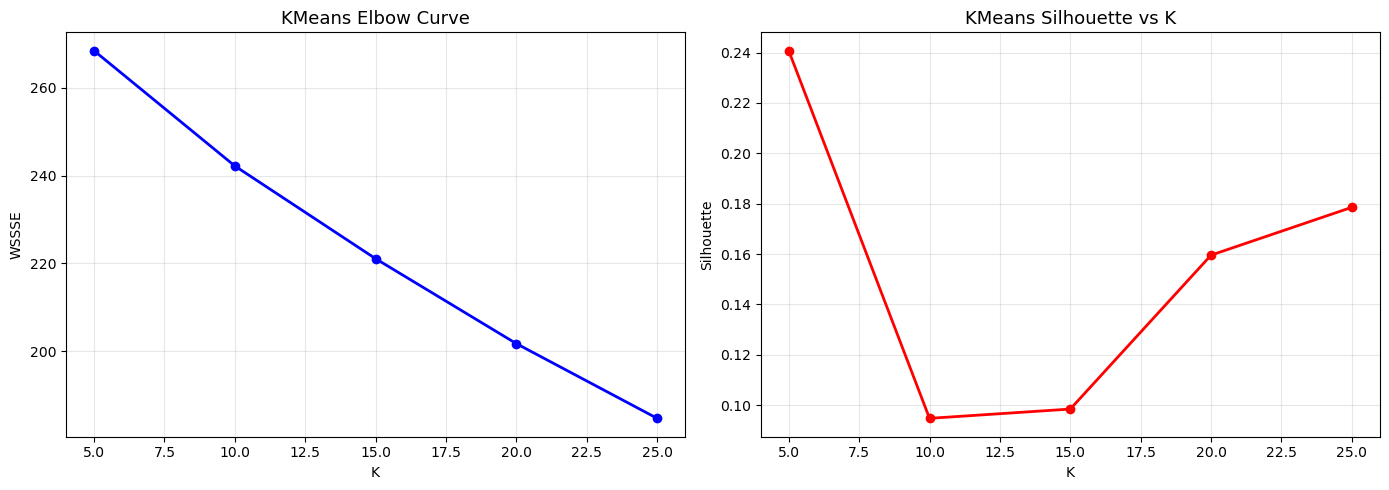

In [9]:
# ── Cell 9: Elbow Plot ────────────────────────────────────────
ks = list(k_range)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, [inertia_scores[k] for k in ks], 'b-o', linewidth=2)
axes[0].set_title('KMeans Elbow Curve', fontsize=13)
axes[0].set_xlabel('K'); axes[0].set_ylabel('WSSSE')
axes[0].grid(True, alpha=0.3)
axes[1].plot(ks, [silhouette_scores[k] for k in ks], 'r-o', linewidth=2)
axes[1].set_title('KMeans Silhouette vs K', fontsize=13)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Hyperparameter tuning (TrainValidationSplit) …
  Tuning done in 9.93s

  KMeans:
    Best K: 10
    Silhouette (test): 0.1132
    Training Cost: 242.22
    Tuning Time (s): 9.93


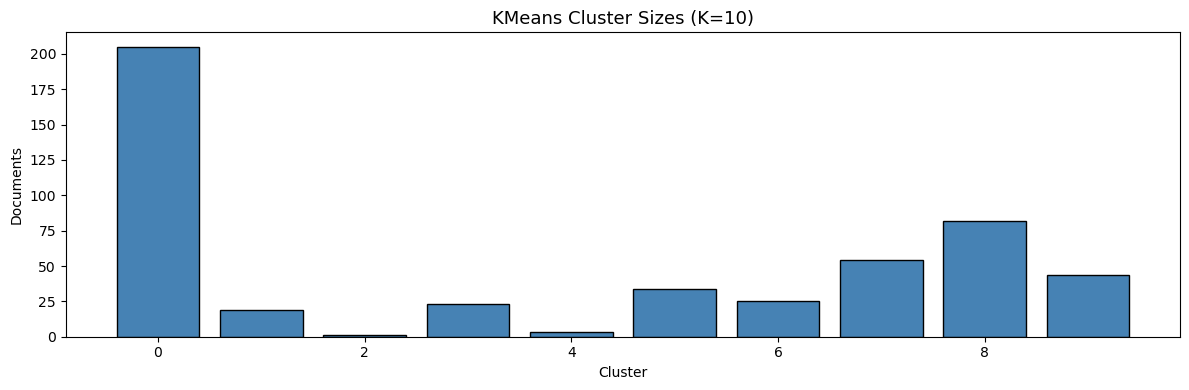

In [10]:
# ── Cell 10: KMeans Hyperparameter Tuning ────────────────────
print("Hyperparameter tuning (TrainValidationSplit) …")
km_tune = KMeans(
    featuresCol="pca_50_features",
    predictionCol="cluster",
    seed=42
)
param_grid = ParamGridBuilder() \
    .addGrid(km_tune.k,       [best_k, best_k + 5]) \
    .addGrid(km_tune.maxIter, [30, 50]) \
    .addGrid(km_tune.tol,     [1e-4, 1e-3]) \
    .build()
tvs = TrainValidationSplit(
    estimator=km_tune,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.8, parallelism=1, seed=42
)
t0_tune   = time.time()
tvs_model = tvs.fit(train_sdf)
tune_elapsed = time.time() - t0_tune
print(f"  Tuning done in {tune_elapsed:.2f}s")

best_km_model = tvs_model.bestModel
km_test_preds = best_km_model.transform(test_sdf)
km_sil_test   = evaluator.evaluate(km_test_preds)
log_result("KMeans", {
    "Best K":            best_km_model._java_obj.getK(),
    "Silhouette (test)": round(km_sil_test, 4),
    "Training Cost":     round(best_km_model.summary.trainingCost, 2),
    "Tuning Time (s)":   round(tune_elapsed, 2),
})
best_km_model.write().overwrite().save("./models/kmeans_best")

# Cluster size plot
cluster_sizes = (
    km_test_preds.groupBy("cluster").count().orderBy("cluster").toPandas()
)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(cluster_sizes['cluster'], cluster_sizes['count'],
       color='steelblue', edgecolor='black')
ax.set_title(
    f'KMeans Cluster Sizes (K={best_km_model._java_obj.getK()})', fontsize=13)
ax.set_xlabel('Cluster'); ax.set_ylabel('Documents')
plt.tight_layout()
plt.show()

In [11]:
# ── Cell 11: ALGORITHM 2 — Bisecting KMeans ──────────────────
print("\n" + "="*60)
print("ALGORITHM 2: Bisecting KMeans")
print("="*60)

# BisectingKMeans also uses predictionCol="cluster" → same evaluator works
bkm_silhouettes = {}
for k in [10, 15, 20, 25]:
    bkm = BisectingKMeans(
        featuresCol="pca_50_features",
        predictionCol="cluster",
        k=k, maxIter=20, seed=42
    )
    t0 = time.time()
    bkm_m   = bkm.fit(train_sdf)
    elapsed = time.time() - t0
    sil = evaluator.evaluate(bkm_m.transform(val_sdf))
    bkm_silhouettes[k] = sil
    print(f"  BKM K={k}: Silhouette={sil:.4f}  Time={elapsed:.2f}s")

best_bkm_k = max(bkm_silhouettes, key=bkm_silhouettes.get)
print(f"Best BKM K: {best_bkm_k}")

bkm_final = BisectingKMeans(
    featuresCol="pca_50_features",
    predictionCol="cluster",
    k=best_bkm_k, maxIter=50, seed=42
)
t0 = time.time()
bkm_model_final = bkm_final.fit(train_sdf)
bkm_elapsed     = time.time() - t0
bkm_test_preds  = bkm_model_final.transform(test_sdf)
bkm_sil_test    = evaluator.evaluate(bkm_test_preds)
log_result("BisectingKMeans", {
    "Best K":            best_bkm_k,
    "Silhouette (test)": round(bkm_sil_test, 4),
    "Training Cost":     round(bkm_model_final.summary.trainingCost, 2),
    "Training Time (s)": round(bkm_elapsed, 2),
})
bkm_model_final.write().overwrite().save("./models/bisecting_kmeans_best")


ALGORITHM 2: Bisecting KMeans
  BKM K=10: Silhouette=0.0602  Time=3.23s
  BKM K=15: Silhouette=0.0300  Time=2.93s
  BKM K=20: Silhouette=0.0411  Time=3.46s
  BKM K=25: Silhouette=0.0407  Time=3.28s
Best BKM K: 10

  BisectingKMeans:
    Best K: 10
    Silhouette (test): 0.0742
    Training Cost: 241.13
    Training Time (s): 5.75


In [12]:
# ── Cell 12: ALGORITHM 3 — LDA Topic Modeling ────────────────
print("\n" + "="*60)
print("ALGORITHM 3: LDA Topic Modeling (tf_features)")
print("="*60)

lda_full  = tfidf_sdf.select("docID", "tf_features")
lda_train, lda_val, lda_test = lda_full.randomSplit([0.70, 0.15, 0.15], seed=42)
lda_train.cache(); lda_test.cache()

lda_perplexity = {}
for n_topics in [10, 15, 20, 30]:
    lda = LDA(
        featuresCol="tf_features", k=n_topics, maxIter=20,
        optimizer="online", learningOffset=1024.0,
        learningDecay=0.51, subsamplingRate=0.05, seed=42
    )
    t0 = time.time()
    lda_m   = lda.fit(lda_train)
    elapsed = time.time() - t0
    perp    = lda_m.logPerplexity(lda_test)
    lda_perplexity[n_topics] = perp
    print(f"  LDA k={n_topics}: Perplexity={perp:.4f}  "
          f"LogLik={lda_m.logLikelihood(lda_test):.2f}  Time={elapsed:.2f}s")

best_n_topics = min(lda_perplexity, key=lda_perplexity.get)
print(f"\nBest LDA k: {best_n_topics}")

lda_final = LDA(
    featuresCol="tf_features", k=best_n_topics, maxIter=50,
    optimizer="online", learningOffset=1024.0,
    learningDecay=0.51, subsamplingRate=0.05, seed=42
)
t0 = time.time()
lda_model_final = lda_final.fit(lda_train)
lda_elapsed     = time.time() - t0
log_result("LDA", {
    "Num Topics":            best_n_topics,
    "Log Perplexity (test)": round(lda_model_final.logPerplexity(lda_test), 4),
    "Log Likelihood (test)": round(lda_model_final.logLikelihood(lda_test), 2),
    "Training Time (s)":     round(lda_elapsed, 2),
    "Vocab Size":            lda_model_final.vocabSize(),
})
lda_model_final.write().overwrite().save("./models/lda_best")


ALGORITHM 3: LDA Topic Modeling (tf_features)
  LDA k=10: Perplexity=8.8991  LogLik=-609505.59  Time=22.88s
  LDA k=15: Perplexity=9.7444  LogLik=-667404.68  Time=24.55s
  LDA k=20: Perplexity=10.7301  LogLik=-734914.87  Time=27.09s
  LDA k=30: Perplexity=13.0799  LogLik=-895852.73  Time=35.61s

Best LDA k: 10

  LDA:
    Num Topics: 10
    Log Perplexity (test): 8.5999
    Log Likelihood (test): -589014.44
    Training Time (s): 44.62
    Vocab Size: 6898


  Topic  0: afscme, seiu, endorsement, union, unions, disapprove, approve, mcentee …
  Topic  1: toomey, specter, donors, hoeffel, murphy, stork, matsunaka, jim …
  Topic  2: iraq, war, military, iraqi, american, soldiers, troops, forces …
  Topic  3: iraq, bush, november, war, enlisted, troops, kerry, vote …
  Topic  4: coffee, mcdonalds, stella, liebeck, colmes, oceana, pataki, burns …
  Topic  5: ditka, martinez, trippi, campaign, dean, surgery, castor, prostate …
  Topic  6: brokaw, scalia, judge, islam, judges, judicial, november, conduct …
  Topic  7: granholm, devos, conservatives, social, keyes, daughter, gay, ethic …
  Topic  8: november, house, senate, poll, republicans, governor, electoral, account …
  Topic  9: bush, kerry, democratic, campaign, poll, dean, general, president …


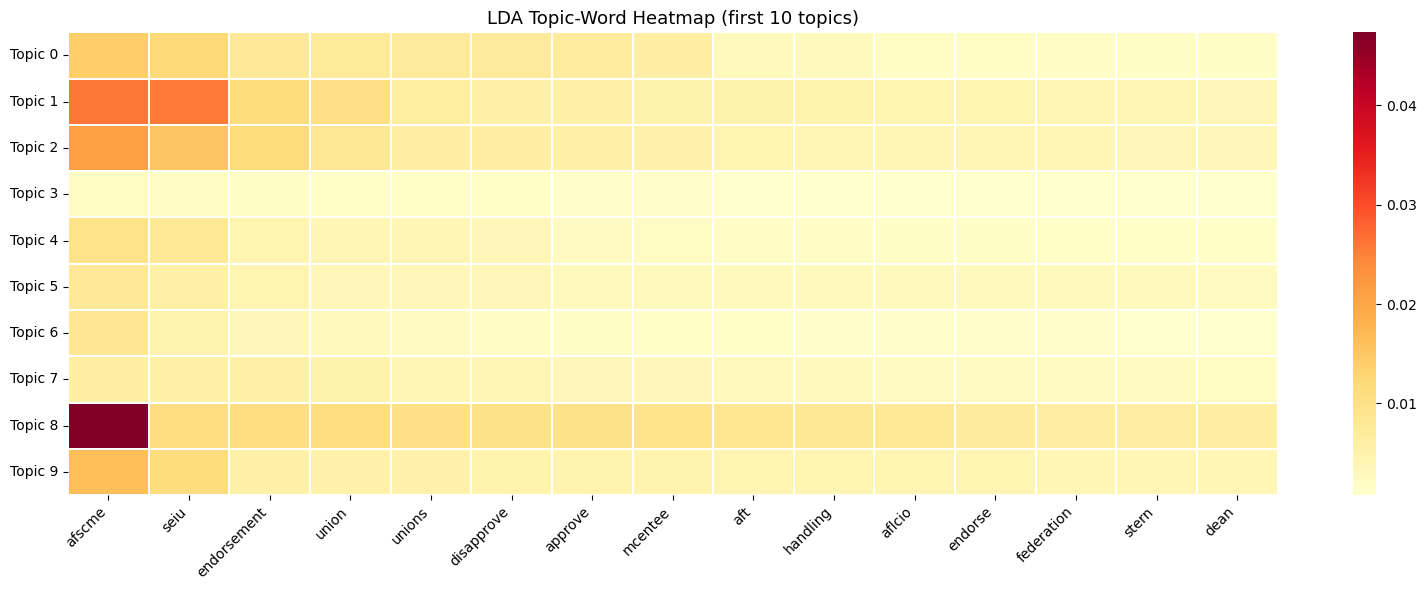

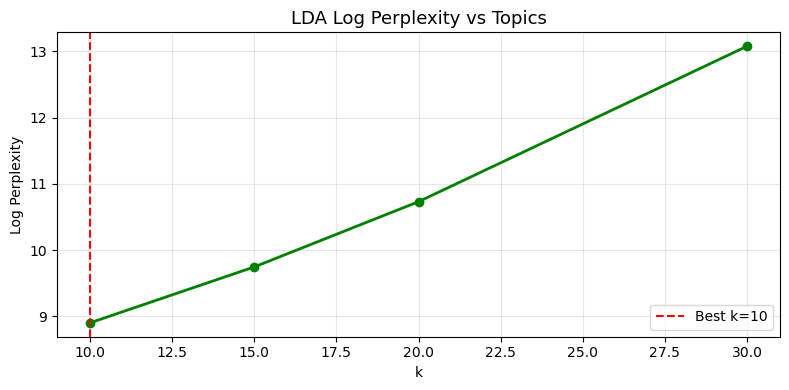

In [14]:
# ── Cell 13: LDA Topic Inspection ────────────────────────────
N_TERMS  = 15   # single constant used everywhere below
topics_pd = lda_model_final.describeTopics(maxTermsPerTopic=N_TERMS).toPandas()
topic_words_dict = {}
for _, row in topics_pd.iterrows():
    tid   = int(row['topic'])
    words = [cv_vocabulary[i] if i < len(cv_vocabulary) else f"<{i}>"
             for i in row['termIndices']]
    wts   = row['termWeights']
    topic_words_dict[tid] = list(zip(words, wts))
    print(f"  Topic {tid:2d}: {', '.join(words[:8])} …")

# Heatmap — matrix shape (n_show, N_TERMS) must match what describeTopics returned
n_show   = min(10, best_n_topics)
mat      = np.zeros((n_show, N_TERMS))   # ← was hardcoded 20, now N_TERMS=15
labels_x = []
for t_id in range(n_show):
    ww = topic_words_dict[t_id][:N_TERMS]
    mat[t_id] = [w for _, w in ww]
    if t_id == 0:
        labels_x = [w for w, _ in ww]
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(mat, xticklabels=labels_x,
            yticklabels=[f"Topic {i}" for i in range(n_show)],
            cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title(f'LDA Topic-Word Heatmap (first {n_show} topics)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./outputs/lda_topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Perplexity line plot
fig, ax = plt.subplots(figsize=(8, 4))
ks2 = sorted(lda_perplexity.keys())
ax.plot(ks2, [lda_perplexity[k] for k in ks2], 'g-o', linewidth=2)
ax.axvline(best_n_topics, color='red', linestyle='--',
           label=f'Best k={best_n_topics}')
ax.set_title('LDA Log Perplexity vs Topics', fontsize=13)
ax.set_xlabel('k'); ax.set_ylabel('Log Perplexity')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/lda_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Cell 14: ALGORITHM 4 — GMM (sklearn, driver-only) ────────
print("\n" + "="*60)
print("ALGORITHM 4: Gaussian Mixture Model (sklearn)")
print("="*60)

gmm_results = {}
for n in [10, 15, 20]:
    gmm = SKLearnGMM(n_components=n, covariance_type='diag',
                     max_iter=100, random_state=42, n_init=3)
    t0 = time.time()
    gmm.fit(X_train_norm)
    elapsed = time.time() - t0
    labels  = gmm.predict(X_test_norm)
    bic     = gmm.bic(X_test_norm)
    sil     = sk_silhouette(X_test_norm[:500], labels[:500])
    gmm_results[n] = {'sil': sil, 'bic': bic, 'time': elapsed}
    print(f"  GMM n={n}: Silhouette={sil:.4f}  BIC={bic:.2e}  Time={elapsed:.2f}s")

best_gmm_n = min(gmm_results, key=lambda k: gmm_results[k]['bic'])
gmm_final  = SKLearnGMM(n_components=best_gmm_n, covariance_type='diag',
                         max_iter=200, random_state=42)
t0 = time.time()
gmm_final.fit(X_train_norm)
gmm_time   = time.time() - t0
gmm_labels = gmm_final.predict(X_test_norm)
gmm_sil    = sk_silhouette(X_test_norm[:500], gmm_labels[:500])
log_result("GMM (sklearn)", {
    "N Components":             best_gmm_n,
    "Silhouette (test, n≤500)": round(gmm_sil, 4),
    "BIC (test)":               round(gmm_final.bic(X_test_norm), 2),
    "Training Time (s)":        round(gmm_time, 2),
})
with open("./models/gmm_final.pkl", "wb") as f:
    pickle.dump(gmm_final, f)
print("GMM saved.")


ALGORITHM 4: Gaussian Mixture Model (sklearn)
  GMM n=10: Silhouette=0.0738  BIC=-3.32e+04  Time=0.47s
  GMM n=15: Silhouette=0.0643  BIC=-3.14e+04  Time=0.23s
  GMM n=20: Silhouette=0.0594  BIC=-2.91e+04  Time=0.25s

  GMM (sklearn):
    N Components: 10
    Silhouette (test, n≤500): 0.0776
    BIC (test): -33212.71
    Training Time (s): 0.04
GMM saved.


In [16]:
# ── Cell 15: sklearn KMeans baseline ─────────────────────────
t0 = time.time()
skm = SKLearnKMeans(n_clusters=best_k, max_iter=100, random_state=42, n_init=5)
skm.fit(X_train_norm)
skm_time   = time.time() - t0
skm_labels = skm.predict(X_test_norm)
skm_sil    = sk_silhouette(X_test_norm[:500], skm_labels[:500])
print(f"sklearn KMeans baseline: Silhouette={skm_sil:.4f}  Time={skm_time:.2f}s")
results["KMeans (sklearn baseline)"] = {
    "Silhouette (test)": round(skm_sil, 4),
    "Training Time (s)": round(skm_time, 2),
}

sklearn KMeans baseline: Silhouette=0.0978  Time=0.04s


In [17]:
# ── Cell 16: Strong Scaling ───────────────────────────────────
print("\n" + "="*60)
print("SCALABILITY: Strong Scaling")
print("="*60)

# Union train+val+test to get full dataset with pca_50_features
full_sdf = (
    train_sdf.select("docID", "pca_50_features")
    .union(val_sdf.select("docID", "pca_50_features"))
    .union(test_sdf.select("docID", "pca_50_features"))
)
full_sdf.cache()
full_count = full_sdf.count()
print(f"Full dataset: {full_count:,} docs")

strong_results = []
for n_parts in [2, 4, 6, 8]:
    data_r = full_sdf.repartition(n_parts)
    km_s   = KMeans(featuresCol="pca_50_features", predictionCol="cluster",
                    k=best_k, maxIter=20, seed=42)
    t0 = time.time()
    km_s.fit(data_r)
    elapsed = time.time() - t0
    strong_results.append({'partitions': n_parts, 'time_s': elapsed,
                            'docs': full_count})
    print(f"  Partitions={n_parts}: {elapsed:.2f}s")


SCALABILITY: Strong Scaling
Full dataset: 3,430 docs
  Partitions=2: 1.79s
  Partitions=4: 1.77s
  Partitions=6: 1.96s
  Partitions=8: 2.49s


In [18]:
# ── Cell 17: Weak Scaling ─────────────────────────────────────
print("\nWeak Scaling:")
weak_results = []
for frac in [0.25, 0.50, 0.75, 1.0]:
    n_docs  = int(full_count * frac)
    n_parts = max(1, int(4 * frac))
    subset  = full_sdf.limit(n_docs).repartition(n_parts)
    km_w    = KMeans(featuresCol="pca_50_features", predictionCol="cluster",
                     k=best_k, maxIter=20, seed=42)
    t0 = time.time()
    km_w.fit(subset)
    elapsed = time.time() - t0
    weak_results.append({'fraction': frac, 'docs': n_docs,
                         'partitions': n_parts, 'time_s': elapsed})
    print(f"  Frac={frac:.2f}  Docs={n_docs:,}  Parts={n_parts}: {elapsed:.2f}s")


Weak Scaling:
  Frac=0.25  Docs=857  Parts=1: 0.89s
  Frac=0.50  Docs=1,715  Parts=2: 1.01s
  Frac=0.75  Docs=2,572  Parts=3: 1.50s
  Frac=1.00  Docs=3,430  Parts=4: 1.64s


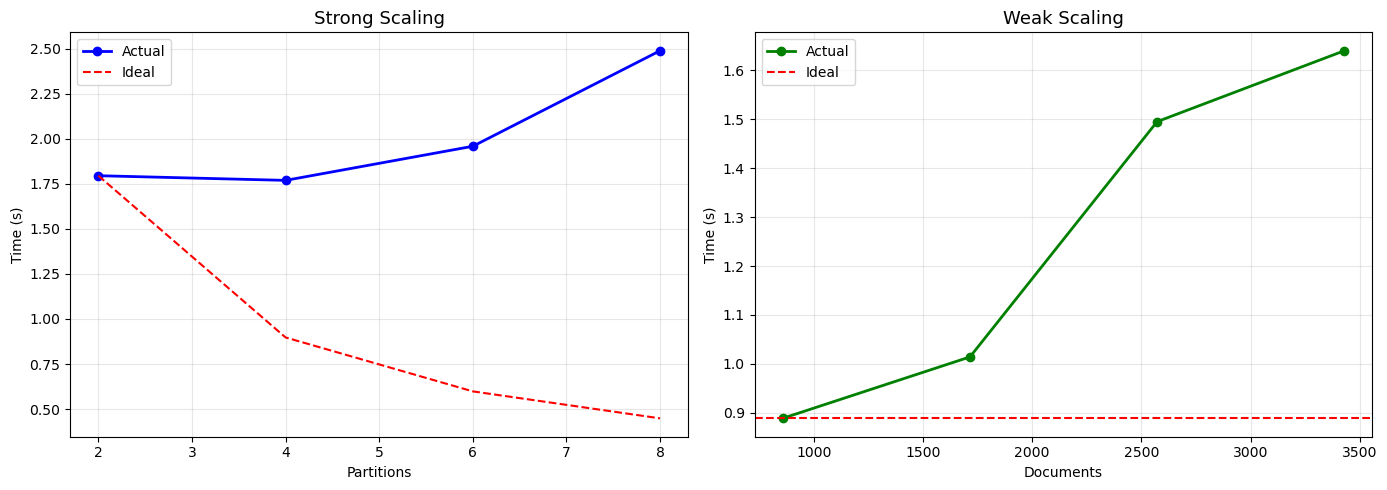

Scalability CSVs saved.


In [19]:
# ── Cell 18: Scalability Plots ────────────────────────────────
ss_df = pd.DataFrame(strong_results)
ws_df = pd.DataFrame(weak_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ideal = (ss_df['time_s'].iloc[0] *
         ss_df['partitions'].iloc[0] / ss_df['partitions'])
axes[0].plot(ss_df['partitions'], ss_df['time_s'], 'b-o',
             label='Actual', linewidth=2)
axes[0].plot(ss_df['partitions'], ideal, 'r--',
             label='Ideal',  linewidth=1.5)
axes[0].set_title('Strong Scaling', fontsize=13)
axes[0].set_xlabel('Partitions'); axes[0].set_ylabel('Time (s)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ws_df['docs'], ws_df['time_s'], 'g-o',
             label='Actual', linewidth=2)
axes[1].axhline(ws_df['time_s'].iloc[0], color='r', linestyle='--',
                label='Ideal')
axes[1].set_title('Weak Scaling', fontsize=13)
axes[1].set_xlabel('Documents'); axes[1].set_ylabel('Time (s)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/scalability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
ss_df.to_csv('./outputs/strong_scaling.csv', index=False)
ws_df.to_csv('./outputs/weak_scaling.csv',   index=False)
print("Scalability CSVs saved.")

In [20]:
# ── Cell 19: Save Results & Cluster Labels ────────────────────
spark.sparkContext.setCheckpointDir("./checkpoints")
with open("./outputs/training_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("training_results.json saved.")

# Save test cluster labels as CSV for NB4
km_label_pd  = (km_test_preds.select("docID", "cluster")
                .toPandas().rename(columns={"cluster": "km_cluster"}))
bkm_label_pd = (bkm_test_preds.select("docID", "cluster")
                .toPandas().rename(columns={"cluster": "bkm_cluster"}))
gmm_label_pd = pd.DataFrame({"docID": test_ids, "gmm_cluster": gmm_labels})
skm_label_pd = pd.DataFrame({"docID": test_ids, "skm_cluster": skm_labels})

labels_pd = (km_label_pd
             .merge(bkm_label_pd, on="docID")
             .merge(gmm_label_pd, on="docID")
             .merge(skm_label_pd, on="docID"))
labels_pd.to_csv("./outputs/test_cluster_labels.csv", index=False)
print(f"Cluster labels saved: {len(labels_pd):,} test docs")

print("\nFinal Results:")
for name, m in results.items():
    print(f"\n  {name}:")
    for k, v in m.items():
        print(f"    {k}: {v}")


training_results.json saved.
Cluster labels saved: 490 test docs

Final Results:

  KMeans:
    Best K: 10
    Silhouette (test): 0.1132
    Training Cost: 242.22
    Tuning Time (s): 9.93

  BisectingKMeans:
    Best K: 10
    Silhouette (test): 0.0742
    Training Cost: 241.13
    Training Time (s): 5.75

  LDA:
    Num Topics: 10
    Log Perplexity (test): 8.5999
    Log Likelihood (test): -589014.44
    Training Time (s): 44.62
    Vocab Size: 6898

  GMM (sklearn):
    N Components: 10
    Silhouette (test, n≤500): 0.0776
    BIC (test): -33212.71
    Training Time (s): 0.04

  KMeans (sklearn baseline):
    Silhouette (test): 0.0978
    Training Time (s): 0.04


In [21]:
# ── Cell 20: Cleanup ──────────────────────────────────────────
full_sdf.unpersist()
lda_train.unpersist()
lda_test.unpersist()
print("\nNotebook 3 complete ✓")


Notebook 3 complete ✓
